In [28]:
import pickle

with open('/home/s6moakba/Thesis/Perplexity_check/perplexity_results_og.pkl', 'rb') as file:
    perplexity_og_result = pickle.load(file)

print(perplexity_og_result['mean_perplexity'])

261.6266531755924


In [29]:
import pickle

with open('/home/s6moakba/Thesis/Perplexity_check/perplexity_results_agentic.pkl', 'rb') as file:
    perplexity_agentic = pickle.load(file)

print(perplexity_agentic['mean_perplexity'])

109.67463292863634


In [30]:
import pickle

with open('/home/s6moakba/Thesis/Perplexity_check/perplexity_results_promting.pkl', 'rb') as file:
    perplexity_prompting = pickle.load(file)

print(perplexity_prompting['mean_perplexity'])

104.73769030359057


In [55]:
import random

og_result = perplexity_og_result['perplexities']

# Sample 90% of the original result
random.seed(42)  # For reproducibility
sample_size = int(len(perplexity_og_result['perplexities']) * 0.9)
og_result = random.sample(perplexity_og_result['perplexities'], sample_size)

# Print mean perplexity of original result

agentic_result = perplexity_agentic['perplexities']
prompting_result = perplexity_prompting['perplexities']

In [56]:
print(len(og_result))
print(len(agentic_result))
print(len(prompting_result))

1800
1800
1800


# Range 

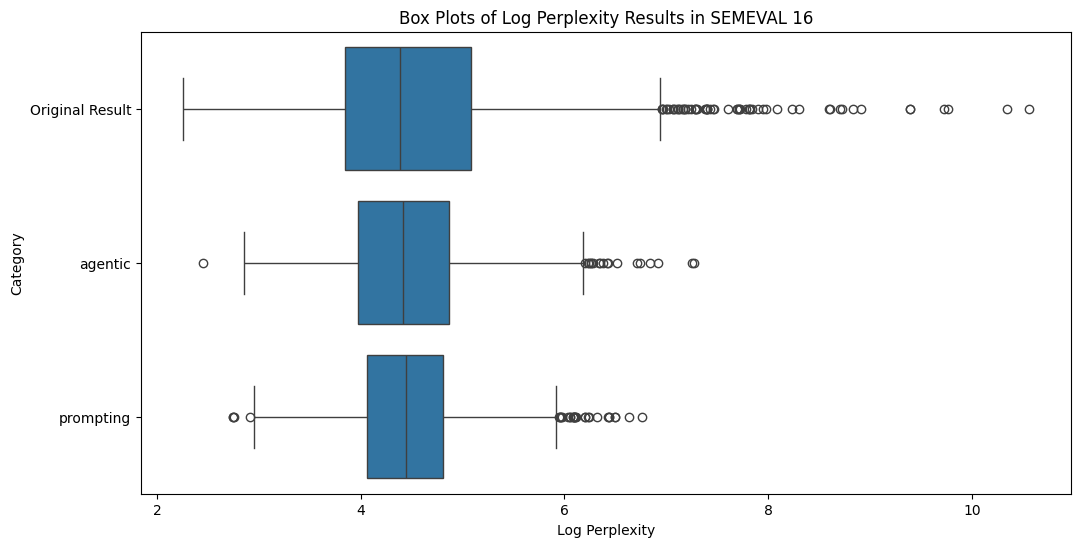

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Combine all results into a single DataFrame for plotting
data = {
    'Original Result': og_result,
    'agentic': agentic_result,
    'prompting': prompting_result
}

# Combine all results into a single DataFrame for plotting
df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data.items()]))

df_melted = df.melt(var_name='Category', value_name='Perplexity')

# Apply logarithmic transformation to the perplexity values
df_melted['Log Perplexity'] = np.log(df_melted['Perplexity'])

# Plot the box plots with x-axis as range of log perplexity
plt.figure(figsize=(12, 6))
sns.boxplot(x='Log Perplexity', y='Category', data=df_melted, orient='h')
plt.title('Box Plots of Log Perplexity Results in SEMEVAL 16')
plt.xlabel('Log Perplexity')
plt.ylabel('Category')
plt.show()

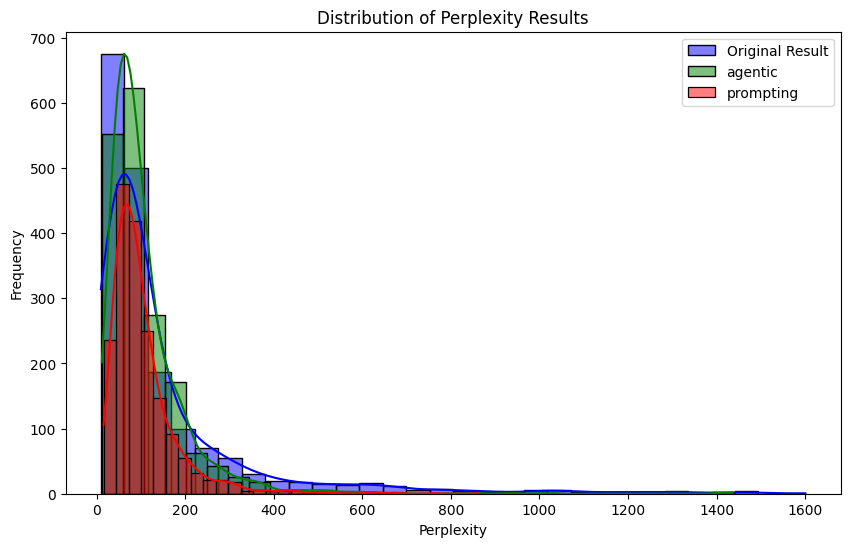

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Remove outliers by filtering data within the 5th and 95th percentiles
og_filtered = [x for x in og_result if  x <= np.percentile(og_result, 98)]

agentic_filtered = [x for x in agentic_result if  x <= np.percentile(agentic_result, 95)]
prompting_filtered = [x for x in prompting_result if x <= np.percentile(prompting_result, 95)]

# Calculate percentiles for filtering


# Apply logarithmic transformation to the values
# og_log = np.log10(og_filtered)
# agentic_log = np.log10(agentic_filtered)
# prompting_log = np.log10(prompting_filtered)

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(og_filtered, color='blue', label='Original Result', kde=True, bins=30)
sns.histplot(agentic_result, color='green', label='agentic', kde=True, bins=30)
sns.histplot(prompting_result, color='red', label='prompting', kde=True, bins=30)

plt.legend()
plt.title('Distribution of Perplexity Results')
plt.xlabel('Perplexity')
plt.ylabel('Frequency')
plt.show()

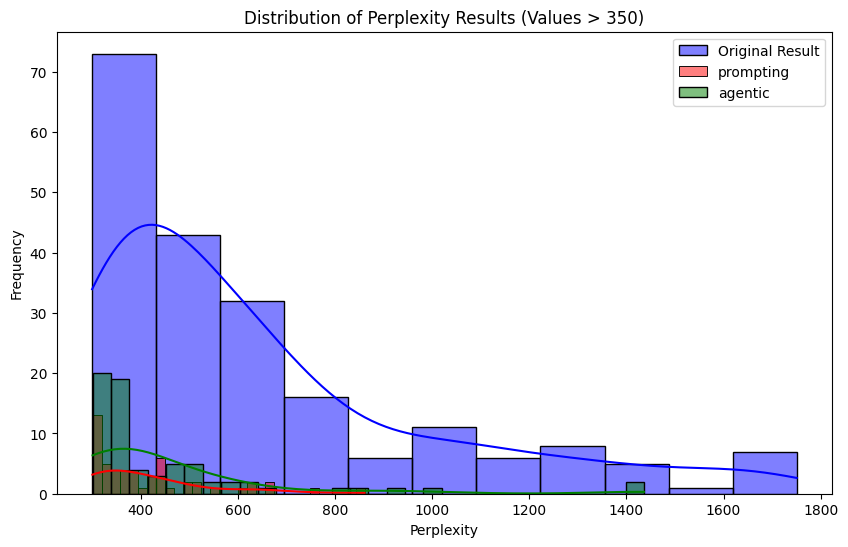

In [69]:
# Filter results to include only values greater than 350
og_filtered_high = [x for x in og_result if x > 300 and x < 2000]
val_right_filtered_high = [x for x in agentic_result if x > 300]
val_wrong_filtered_high = [x for x in prompting_result if x > 300]

# Plot the distribution for values greater than 350
plt.figure(figsize=(10, 6))
sns.histplot(og_filtered_high, color='blue', label='Original Result', kde=True)
sns.histplot(val_wrong_filtered_high, color='red', label='prompting', kde=True, bins=30)
sns.histplot(val_right_filtered_high, color='green', label='agentic', kde=True, bins=30)

plt.legend()
plt.title('Distribution of Perplexity Results (Values > 350)')
plt.xlabel('Perplexity')
plt.ylabel('Frequency')
plt.show()
